<a href="https://colab.research.google.com/github/wesleylelo/CDIA_AI_COLAB/blob/develop/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###################################################################
##################################################################
#Instituição: SENAI - CIMATEC
#Curso: Ciência de Dados e Inteligência Artificial (CDIA)
#Disciplina: Inteligência Artificial II
#Autor: Carlos Fernando Arraz | Data: Fevereiro, 2024
#UA06 - Roteiro de Prática Guiada 01: Redes RNN
###################################################################
###################################################################

---

INSTRUÇÕES GERAIS:

---



1 - Realize uma cópia deste arquivo em seu repositório pessoal para iniciar a prática (usar o e-mail institucional para isso);

2 - Reveja o conteúdo teórico e os exemplos práticos vistos até agora na graduação para pontecializar o aprendizado;

3 -Leia a teoria e acompanhe o script python linha a linha e seus comentários (execute as células com **shift + ENTER** ou botão play à esquerda de cada comando/bloco de código), estudando as estruturas, as partes do algoritmo e a lógica proposta;

4 - Execute, modifique, teste e experimente o conteúdo ao máximo para internalizar o conhecimento; e

5- Compare os resultados com bibliotecas de machine learning consagradas no desenvolvimento de soluções em AI.

#Este roteiro tem como objetivo mostrar uma introdução de uma rede neural recorrente (RNN) através de um script em python 🐍.



# Tarefa I: Usando um RNN Simples para Previsão [4][5]

Neste laboratório você começará a usar redes neurais recorrentes (RNNs) para construir um modelo de previsão. Em particular, você irá:

* construir um RNN empilhado usando camadas `simpleRNN`
* usar camadas `Lambda` para remodelar a entrada e dimensionar a saída
* usar a função de perda de Huber durante o treinamento
* usar janelas de dados em lote para gerar previsões de modelo

Você treinará isso no mesmo conjunto de dados sintético. Vamos lá!

## Importações

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Utilitários

In [2]:
def plot_series(time, series, format="-", start=0, end=None):
    """
    Visualizes time series data

    Args:
      time (array of int) - contains the time steps
      series (array of int) - contains the measurements for each time step
      format - line style when plotting the graph
      start - first time step to plot
      end - last time step to plot
    """

    # Setup dimensions of the graph figure
    plt.figure(figsize=(10, 6))

    if type(series) is tuple:

      for series_num in series:
        # Plot the time series data
        plt.plot(time[start:end], series_num[start:end], format)

    else:
      # Plot the time series data
      plt.plot(time[start:end], series[start:end], format)

    # Label the x-axis
    plt.xlabel("Time")

    # Label the y-axis
    plt.ylabel("Value")

    # Overlay a grid on the graph
    plt.grid(True)

    # Draw the graph on screen
    plt.show()

def trend(time, slope=0):
    """
    Generates synthetic data that follows a straight line given a slope value.

    Args:
      time (array of int) - contains the time steps
      slope (float) - determines the direction and steepness of the line

    Returns:
      series (array of float) - measurements that follow a straight line
    """

    # Compute the linear series given the slope
    series = slope * time

    return series

def seasonal_pattern(season_time):
    """
    Just an arbitrary pattern, you can change it if you wish

    Args:
      season_time (array of float) - contains the measurements per time step

    Returns:
      data_pattern (array of float) -  contains revised measurement values according
                                  to the defined pattern
    """

    # Generate the values using an arbitrary pattern
    data_pattern = np.where(season_time < 0.4,
                    np.cos(season_time * 2 * np.pi),
                    1 / np.exp(3 * season_time))

    return data_pattern

def seasonality(time, period, amplitude=1, phase=0):
    """
    Repeats the same pattern at each period

    Args:
      time (array of int) - contains the time steps
      period (int) - number of time steps before the pattern repeats
      amplitude (int) - peak measured value in a period
      phase (int) - number of time steps to shift the measured values

    Returns:
      data_pattern (array of float) - seasonal data scaled by the defined amplitude
    """

    # Define the measured values per period
    season_time = ((time + phase) % period) / period

    # Generates the seasonal data scaled by the defined amplitude
    data_pattern = amplitude * seasonal_pattern(season_time)

    return data_pattern

def noise(time, noise_level=1, seed=None):
    """Generates a normally distributed noisy signal

    Args:
      time (array of int) - contains the time steps
      noise_level (float) - scaling factor for the generated signal
      seed (int) - number generator seed for repeatability

    Returns:
      noise (array of float) - the noisy signal
    """

    # Initialize the random number generator
    rnd = np.random.RandomState(seed)

    # Generate a random number for each time step and scale by the noise level
    noise = rnd.randn(len(time)) * noise_level

    return noise

## Gerando dados sintéticos

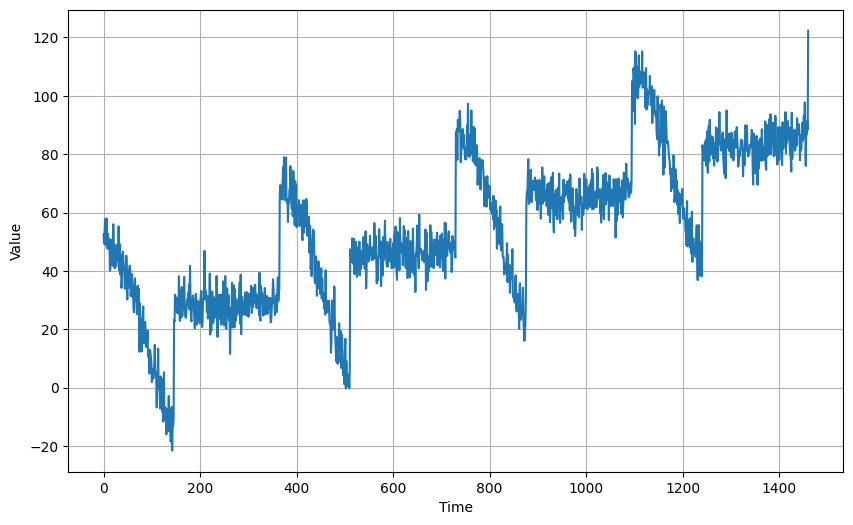

In [ ]:
# Parameters
time = np.arange(4 * 365 + 1, dtype="float32")
baseline = 10
amplitude = 40
slope = 0.05
noise_level = 5

# Create the series
series = baseline + trend(time, slope) + seasonality(time, period=365, amplitude=amplitude)

# Update with noise
series += noise(time, noise_level, seed=42)

# Plot the results
plot_series(time, series)

## Dividir o dataset

In [ ]:
# Define the split time
split_time = 1000

# Get the train set
time_train = time[:split_time]
x_train = series[:split_time]

# Get the validation set
time_valid = time[split_time:]
x_valid = series[split_time:]

## Preprando as variáveis e os rótulos

In [ ]:
# Parameters
window_size = 20
batch_size = 32
shuffle_buffer_size = 1000

In [ ]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    """Generates dataset windows

    Args:
      series (array of float) - contains the values of the time series
      window_size (int) - the number of time steps to include in the feature
      batch_size (int) - the batch size
      shuffle_buffer(int) - buffer size to use for the shuffle method

    Returns:
      dataset (TF Dataset) - TF Dataset containing time windows
    """

    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)

    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    # Create tuples with features and labels
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))

    # Shuffle the windows
    dataset = dataset.shuffle(shuffle_buffer)

    # Create batches of windows
    dataset = dataset.batch(batch_size).prefetch(1)

    return dataset

In [ ]:
# Generate the dataset windows
dataset = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer_size)

In [ ]:
# Print shapes of feature and label
for window in dataset.take(1):
  print(f'shape of feature: {window[0].shape}')
  print(f'shape of label: {window[1].shape}')

shape of feature: (32, 20)
shape of label: (32,)


## Construa o modelo [4][5]

Seu modelo é composto principalmente por camadas [SimpleRNN](https://www.tensorflow.org/api_docs/python/tf/keras/layers/SimpleRNN). Conforme mencionado, este tipo de RNN simplesmente encaminha sua saída de volta para a entrada. Você empilhará duas dessas camadas em seu modelo, então a primeira deve ter `return_sequences` definida como `True`.

Conforme mencionado na [documentação](https://www.tensorflow.org/api_docs/python/tf/keras/layers/SimpleRNN#call_arguments), as camadas `SimpleRNN` esperam uma entrada de tensor tridimensional com a forma `[lote , intervalos de tempo, recurso`]. Com isso, você precisa remodelar sua janela de `(32, 20)` para `(32, 20, 1)`. Isso significa que os 20 pontos de dados na janela serão mapeados para 20 intervalos de tempo do RNN. Você pode fazer essa remodelagem em uma célula separada, mas também pode fazer isso dentro do próprio modelo usando camadas [Lambda](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Lambda). Observe a primeira camada abaixo. Define uma função lambda que adiciona uma dimensão no último eixo da entrada. Essa é exatamente a transformação que você precisa. Para `input_shape`, você pode especificar `None` se quiser que o modelo seja mais flexível com o número de intervalos de tempo. Alternativamente, você pode configurá-lo para `window_size` conforme mostrado abaixo se quiser definir a dimensão `timesteps` para o tamanho esperado de suas janelas de dados.

Normalmente, você pode apenas ter uma saída da camada `Dense`, conforme mostrado anteriormente. No entanto, você pode ajudar no treinamento aumentando a saída para aproximadamente os mesmos valores dos seus rótulos. Isso dependerá das [funções de ativação](https://en.wikipedia.org/wiki/Activation_function#Table_of_activation_functions) que você usou em seu modelo. `SimpleRNN` usa *tanh* por padrão e tem um intervalo de saída de `[-1,1]`. Você usará outra camada `Lambda()` para dimensionar a saída em 100 antes de ajustar os pesos da camada. Sinta-se à vontade para remover essa camada posteriormente após este laboratório e ver os resultados obtidos.

In [ ]:
# Build the Model
model_tune = tf.keras.models.Sequential([
  tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1),
                      input_shape=[window_size]),
  tf.keras.layers.SimpleRNN(40, return_sequences=True),
  tf.keras.layers.SimpleRNN(40),
  tf.keras.layers.Dense(1),
  tf.keras.layers.Lambda(lambda x: x * 100.0)
])

# Print the model summary
model_tune.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                      │ (None, 20, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 20, 40)              │           1,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 40)                  │           3,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              41 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,961 (19.38 KB)

 Trainable params: 4,961 (19.38 KB)

 Non-trainable params: 0 (0.00 B)

## Ajuste a taxa de aprendizagem

Você então ajustará a taxa de aprendizado. Você definirá uma programação de taxa de aprendizagem que altera esse hiperparâmetro dinamicamente. Você usará a [Perda de Huber](https://en.wikipedia.org/wiki/Huber_loss) como sua função de perda para minimizar a sensibilidade a valores discrepantes.

In [ ]:
# Set the learning rate scheduler
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-8 * 10**(epoch / 20))

# Initialize the optimizer
optimizer = tf.keras.optimizers.SGD(momentum=0.9)

# Set the training parameters
model_tune.compile(loss=tf.keras.losses.Huber(), optimizer=optimizer)

# Train the model
history = model_tune.fit(dataset, epochs=100, callbacks=[lr_schedule])

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 48.9820 - learning_rate: 1.0000e-08
Epoch 2/100
 8/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 49.5347  

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 47.8825 - learning_rate: 1.1220e-08
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 45.9811 - learning_rate: 1.2589e-08
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 43.6795 - learning_rate: 1.4125e-08
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 40.4084 - learning_rate: 1.5849e-08
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 36.8563 - learning_rate: 1.7783e-08
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 33.6618 - learning_rate: 1.9953e-08
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 29.2329 - learning_rate: 2.2387e-08
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 27.3915 - learning_rate: 2.5119e-08
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 23.4395 - learning_rate: 2.8184e-08
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 20.8768 - learning_rate: 3.1623e-08
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss:

Você pode visualizar os resultados e escolher uma taxa de aprendizado ideal.

(1e-08, 0.001, 0.0, 50.0)

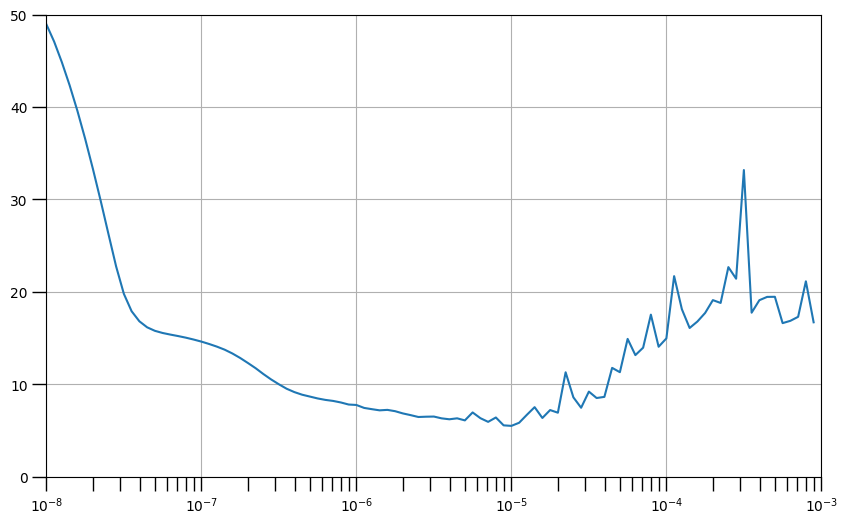

In [ ]:
# Define the learning rate array
lrs = 1e-8 * (10 ** (np.arange(100) / 20))

# Set the figure size
plt.figure(figsize=(10, 6))

# Set the grid
plt.grid(True)

# Plot the loss in log scale
plt.semilogx(lrs, history.history["loss"])

# Increase the tickmarks size
plt.tick_params('both', length=10, width=1, which='both')

# Set the plot boundaries
plt.axis([1e-8, 1e-3, 0, 50])

Você pode alterar os limites do gráfico se quiser aumentar o zoom. A célula abaixo escolhe um intervalo mais estreito para que você possa ver mais claramente onde o gráfico se torna instável.

(1e-07, 0.0001, 0.0, 20.0)

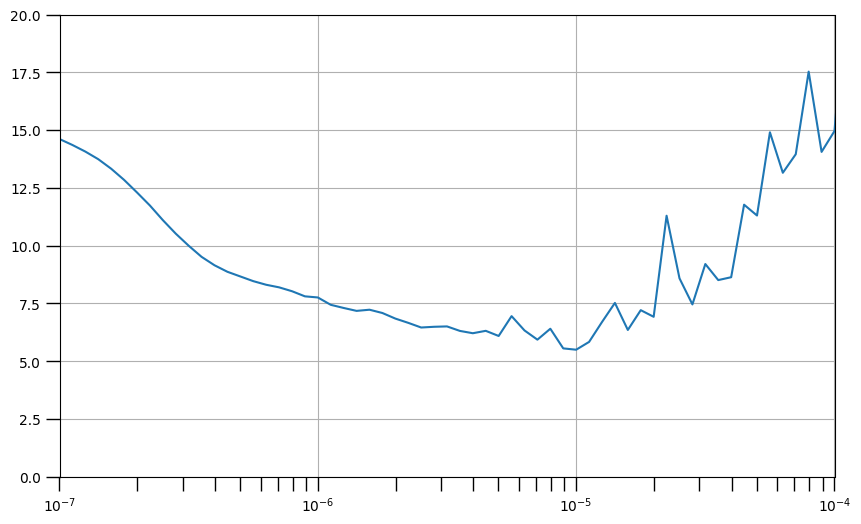

In [ ]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Set the grid
plt.grid(True)

# Plot the loss in log scale
plt.semilogx(lrs, history.history["loss"])

# Increase the tickmarks size
plt.tick_params('both', length=10, width=1, which='both')

# Set the plot boundaries
plt.axis([1e-7, 1e-4, 0, 20])

## Treine o modelo

Você pode então declarar o modelo novamente e treinar com a taxa de aprendizado escolhida. Ele está definido como `1e-6` por padrão, mas fique à vontade para alterá-lo.

In [ ]:
# Build the model
model = tf.keras.models.Sequential([
  tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1),
                      input_shape=[window_size]),
  tf.keras.layers.SimpleRNN(40, return_sequences=True),
  tf.keras.layers.SimpleRNN(40),
  tf.keras.layers.Dense(1),
  tf.keras.layers.Lambda(lambda x: x * 100.0)
])

# Set the learning rate
learning_rate = 1e-6

# Set the optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

# Set the training parameters
model.compile(loss=tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])

# Train the model
history = model.fit(dataset,epochs=100)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 50.8168 - mae: 51.3158
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 15.6032 - mae: 16.0910
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 11.3695 - mae: 11.8559
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 9.5896 - mae: 10.0711
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.0809 - mae: 8.5629
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.3287 - mae: 9.8155
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.6577 - mae: 9.1351
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.3758 - mae: 7.8572
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.6576 - mae: 8.1339
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.4370 - mae: 7.9187
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.6321 - mae: 8.1097
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.2069 - mae: 7.6840
Epoch 13/100
31/31

## Previsão de modelo

Agora é hora de gerar as previsões do modelo para o intervalo de tempo do conjunto de validação. O modelo é muito maior do que os que você usou antes e a natureza sequencial dos RNNs (ou seja, as entradas passam por uma série de etapas de tempo em vez do processamento paralelo) pode tornar as previsões um pouco lentas.

In [ ]:
# Initialize a list
forecast = []

# Reduce the original series
forecast_series = series[split_time - window_size:]

# Use the model to predict data points per window size
for time in range(len(forecast_series) - window_size):
  forecast.append(model.predict(forecast_series[time:time + window_size][np.newaxis]))

# Convert to a numpy array and drop single dimensional axes
results = np.array(forecast).squeeze()

# Plot the results
plot_series(time_valid, (x_valid, results))

Você pode otimizar esta etapa aproveitando a capacidade dos modelos Tensorflow para processar lotes. Em vez de executar o loop for acima, que processa uma única janela por vez, você pode passar um lote inteiro de janelas e deixar o modelo processá-lo em paralelo.

A função abaixo faz exatamente isso. Você notará que quase espelha a função `windowed_dataset()`, mas não embaralha as janelas. Isso ocorre porque queremos que a saída esteja na sequência correta para que possamos compará-la adequadamente com o conjunto de validação.

In [ ]:
def model_forecast(model, series, window_size, batch_size):
    """Uses an input model to generate predictions on data windows

    Args:
      model (TF Keras Model) - model that accepts data windows
      series (array of float) - contains the values of the time series
      window_size (int) - the number of time steps to include in the window
      batch_size (int) - the batch size

    Returns:
      forecast (numpy array) - array containing predictions
    """

    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size, shift=1, drop_remainder=True)

    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda w: w.batch(window_size))

    # Create batches of windows
    dataset = dataset.batch(batch_size).prefetch(1)

    # Get predictions on the entire dataset
    forecast = model.predict(dataset)

    return forecast

Você pode executar a função abaixo para usar a função. Observe que as previsões são geradas quase instantaneamente.

*Nota: Você pode notar que a primeira linha corta a `series` em `split_time - window_size:-1`, o que é um pouco diferente do código for-loop mais lento. Isso ocorre porque queremos que o modelo tenha sua última previsão alinhada com o último ponto do conjunto de validação (ou seja, `t=1460`). Você foi capaz de fazer isso com o código for-loop mais lento, especificando o `range()` do for-loop. Com a função mais eficiente acima, você não tem esse mecanismo, então basta remover o último ponto ao fatiar a `série`. Caso contrário, a função gerará uma previsão em `t=1461` que está fora do intervalo do conjunto de validação.*

In [ ]:
# Reduce the original series
forecast_series = series[split_time - window_size:-1]

# Use helper function to generate predictions
forecast = model_forecast(model, forecast_series, window_size, batch_size)

# Drop single dimensional axis
results = forecast.squeeze()

# Plot the results
plot_series(time_valid, (x_valid, results))

Você pode então calcular o MSE e o MAE. Você pode comparar os resultados aqui ao usar outras arquiteturas RNN, o que você fará no próximo laboratório.

In [ ]:
# Compute the MSE and MAE
print(tf.keras.metrics.mean_squared_error(x_valid, results).numpy())
print(tf.keras.metrics.mean_absolute_error(x_valid, results).numpy())

Referências:

[1] BISHOP, C. M. (2006). Pattern Recognition and Machine Learning. Springer.

[2] JAMES, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in python. Springer Nature.

[3] FACELI, Katti; et al. Inteligência artificial: uma abordagem de aprendizado de máquina. Rio de Janeiro: Grupo GEN, 2021. E-book. ISBN 9788521637509.

[4] GÉRON, Aurélien. Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow: Conceitos, Ferramentas e Técnicas para a Construção de Sistemas Inteligentes. Editora Alta Books, 2021. E-book. ISBN 9786555208146. Disponível em: https://integrada.minhabiblioteca.com.br/#/books/9786555208146/. Acesso em: 25 fev. 2024.

[5] Conteúdo online modificado da DeepLearning.ai (https://github.com/https-deeplearning-ai ). https://github.com/https-deeplearning-ai/tensorflow-1-public/blob/main/C4/W3/ungraded_labs/C4_W3_Lab_1_RNN.ipynb . Sob licença Apache 2 https://www.apache.org/licenses/LICENSE-2.0 . Acessado 19/02/2024.

